# Kritischer-Pfad-Terminierung einer Kfz-Versicherungsprodukteinführung

## Zusammenfassung für die Geschäftsleitung

Die Einführung eines Kfz-Versicherungsprodukts für Privatkunden ist ein bereichsübergreifendes Programm: Aktuare bepreisen das Risiko, die Compliance-Abteilung reicht die Tarife bei der Aufsichtsbehörde ein und wartet auf die Genehmigung, die IT konfiguriert das Bestandsführungssystem und der Vertrieb schult die Agenten. Diese Aufgaben stehen in harten Vorrangbeziehungen, sodass der Einführungstermin durch die längste abhängige Kette im Plan bestimmt wird -- den **kritischen Pfad**.

Dieses Notebook baut ein Aktivität-auf-Knoten-Projektnetzwerk aus elf Einführungsaufgaben auf und berechnet einen vollständigen **Critical-Path-Method-(CPM)**-Terminplan mit **PROC OPTMODEL**. Der Vorwärts- und Rückwärtsdurchlauf von CPM sind lineare Programme über den Vorranggraphen: Der Vorwärtsdurchlauf (längster Pfad vom Start) liefert für jede Aufgabe den frühesten Start und das früheste Ende, und ein Rückwärts-Längstpfaddurchlauf liefert den spätesten Start und das späteste Ende sowie den **Gesamtpuffer** (Terminplanreserve). Die untenstehenden Ergebnisse werden vollständig durch den Code in diesem Notebook erzeugt -- jede Zahl in der Erzählung wird aus der ausgeführten Ausgabe zurückgelesen.

**Was der Terminplan zeigt.** Auf einem Fünf-Tage-Arbeitskalender, verankert am 01JUN2026, erstreckt sich das Programm über **97 Arbeitstage** und endet am **13OCT2026**. Neun der elf Aufgaben liegen auf dem kritischen Pfad (Kickoff -> Marktforschung -> Schadendatenaufbereitung -> Bepreisung -> Systementwurf -> Systemaufbau -> UAT -> Agentenschulung -> Einführung) und tragen keinen Puffer. Nur der aufsichtsrechtliche Zweig -- **Tarifeinreichung** und **Genehmigung** -- verfügt über Reserve: Jeder kann bis zu **30 Arbeitstage** verrutschen, ohne die Einführung zu verschieben, da der parallele Systemaufbauzweig der längere der beiden zusammenlaufenden Pfade ist.

## Wie dies aufgebaut ist

CPM ist klassisch eine SAS/OR-Prozedur, aber ihre Kernberechnung ist ein Paar von Längstpfadproblemen auf dem Vorranggraphen, die PROC OPTMODEL direkt als kleine lineare Programme ausdrückt:

- **Vorwärtsdurchlauf (früheste Zeiten).** Minimiere die Frühester-Start-Variablen unter der Nebenbedingung `ES[successor] >= ES[predecessor] + duration + lag` für jede Vorrangkante. Im Optimum ist jedes `ES` gleich dem längsten Pfad vom Projektstart, d. h. dem frühesten Zeitpunkt, zu dem die Aufgabe beginnen kann.
- **Rückwärtsdurchlauf (späteste Zeiten / Puffer).** Berechne für jede Aufgabe den längsten verbleibenden Pfad zum Projektende (`TAIL`). Der späteste Start ist dann `makespan - TAIL`, und der **Gesamtpuffer** ist `später Start - früher Start`. Aufgaben mit einem Puffer von null sind kritisch.

Das Netzwerk, die Dauern, die Vorrangverzögerungen und die aufgabenspezifischen Ressourcenbedarfe werden alle inline erzeugt; es gibt keine externen Eingaben. Arbeitstag-Kalenderdaten werden mit `INTNX('weekday', ...)` abgeleitet, sodass Wochenenden übersprungen werden.

## Daten

| Datensatz | Zeilen | Schlüsselvariablen | Beschreibung |
|---------|------|---------------|-------------|
| `acts`  | 11 | `id`, `activity`, `dur`, `actuary`, `developer` | Aktivitätsstamm: jede Einführungsaufgabe, ihre Dauer in Arbeitstagen und der tägliche Aktuar-/Entwickler-Personalbedarf, den sie benötigt |
| `arcs`  | 12 | `pred`, `succ`, `lag` | Vorrangkanten des Aktivität-auf-Knoten-Netzwerks; `lag` ist eine Ende-Anfang-Verzögerung in Arbeitstagen (die aufsichtsrechtliche Wartezeit nach der Genehmigung) |

Numerische Aktivitäts-IDs schlüsseln das Netzwerk, sodass der Vorranggraph sauber in die Tupelmenge von OPTMODEL eingelesen wird; die lesbaren `activity`-Namen werden anschließend wieder an den Terminplan angefügt.

In [1]:
DATEN acts;
   LÄNGE activity $24;
   EINGABE id activity $ dur actuary developer;
   DATALINES;
1 Kickoff 3 1 0
2 Marktforschung 8 2 0
3 Schadendatenaufbereitung 10 3 0
4 Bepreisung 9 3 1
5 Tarifeinreichung 4 1 0
6 Genehmigung 6 1 0
7 Systementwurf 12 1 2
8 Systemaufbau 18 0 3
9 UAT 15 0 2
10 Agentenschulung 20 1 1
11 Einführung 2 1 1
;
AUSFÜHREN;

DATEN arcs;
   EINGABE pred succ lag;
   DATALINES;
1 2 0
2 3 0
3 4 0
4 5 0
4 7 0
5 6 0
6 10 5
7 8 0
8 9 0
9 10 0
9 11 0
10 11 0
;
AUSFÜHREN;

/* Nur-numerische Sicht der Dauern für OPTMODEL */
DATEN acts_n; FESTLEGEN acts; BEHALTEN id dur; AUSFÜHREN;


NOTE: DATA acts

NOTE: Processing inline DATALINES (11 lines)

NOTE: Read 11 rows from DATALINES.
NOTE: Wrote acts (11 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA arcs

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote arcs (12 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA acts_n


NOTE: Read 11 rows from acts.
NOTE: Wrote acts_n (11 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Vorwärtsdurchlauf -- frühester Start und frühestes Ende

Der Vorwärtsdurchlauf ist ein Längstpfad-LP. Die Nebenbedingung `ES[j] >= ES[i] + dur[i] + lag[i,j]` für jede Kante zwingt jede Aufgabe, nicht früher zu beginnen, als alle ihre Vorgänger enden (zuzüglich etwaiger aufsichtsrechtlicher Verzögerung); die Minimierung der Frühester-Start-Variablen treibt jede auf ihren längsten Vorgängerpfad. Wir schreiben die gelösten `ES`-Werte direkt aus der OPTMODEL-Variablen in `fwd`.

In [2]:
PROZEDUR optmodel;
   FESTLEGEN NODES; num dur{NODES};
   READ DATEN acts_n INTO NODES=[id] dur=dur;

   FESTLEGEN <num,num> ARCS; num lag{ARCS};
   READ DATEN arcs INTO ARCS=[pred succ] lag=lag;

   VAR ES{NODES} >= 0;
   con prec{<i,j> in ARCS}:
       ES[j] >= ES[i] + dur[i] + lag[i,j];
   MIN total_es = sum{k in NODES} ES[k];
   solve;

   ERSTELLEN DATEN fwd VON [id]=NODES es=ES;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_ES
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         12

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_ES
  Solution Status               Optimal
  Objective Value               401.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Rückwärtsdurchlauf -- späteste Zeiten und Gesamtpuffer

`TAIL[a]` ist der längste Pfad von Aufgabe `a` bis zum Projektende, daher muss er die eigene Dauer der Aufgabe abdecken und, für jeden Nachfolger, die Verzögerung zuzüglich des Endstücks dieses Nachfolgers: `TAIL[i] >= dur[i] + lag[i,j] + TAIL[j]`. Die Minimierung der Endstücke liefert die engsten solchen Werte. Die Projekt-**Gesamtdauer (Makespan)** ist das größte frühe Ende; der **späte Start** jeder Aufgabe ist `makespan - TAIL`, und der **Gesamtpuffer** ist `später Start - früher Start`. Ein Puffer von null markiert den kritischen Pfad.

In [3]:
PROZEDUR optmodel;
   FESTLEGEN NODES; num dur{NODES};
   READ DATEN acts_n INTO NODES=[id] dur=dur;

   FESTLEGEN <num,num> ARCS; num lag{ARCS};
   READ DATEN arcs INTO ARCS=[pred succ] lag=lag;

   VAR TAIL{NODES} >= 0;
   con BASE{a in NODES}: TAIL[a] >= dur[a];
   con back{<i,j> in ARCS}:
       TAIL[i] >= dur[i] + lag[i,j] + TAIL[j];
   MIN total_tail = sum{k in NODES} TAIL[k];
   solve;

   ERSTELLEN DATEN bwd VON [id]=NODES tail=TAIL;
QUIT;


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            TOTAL_TAIL
  Objective Type                Linear

  Number of Variables           11
  Bounded Above                 0
  Bounded Below                 11
  Bounded Below and Above       0
  Free                          0
  Fixed                         0

  Number of Constraints         23

                          Solution Summary
  Solver                        LP
  Objective Function            TOTAL_TAIL
  Solution Status               Optimal
  Objective Value               606.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Terminplan und Kalender zusammenstellen

Wir fügen die frühen Starts und Endstücke wieder an den Aktivitätsstamm an, leiten den späten Start / das späte Ende und den Gesamtpuffer ab und bilden die Arbeitstag-Versätze mit `INTNX('weekday', ...)` auf Kalenderdaten ab, sodass die Daten auf Werktage fallen. Eine Aufgabe wird als **kritisch** gekennzeichnet, wenn ihr Gesamtpuffer null ist.

In [4]:
%LET anchor = '01jun2026'd;

DATEN sched0;
   ZUSAMMENFÜHREN acts fwd bwd; NACH id;
   ef = es + dur;            /* frühes Ende */
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=sched0 NOPRINT;
   AUSGABE out=mk(ENTFERNEN=_type_ _freq_) MAX(ef)=makespan;
AUSFÜHREN;

DATEN sched;
   WENN _n_=1 DANN FESTLEGEN mk;
   FESTLEGEN sched0;
   BEHALTEN_W mspan;
   WENN _n_=1 DANN mspan = makespan;
   ls = mspan - tail;        /* später Start */
   lf = ls + dur;            /* spätes Ende  */
   tfloat = ls - es;         /* Gesamtpuffer */
   e_start  = intnx('weekday', &anchor, es,   'b');
   e_finish = intnx('weekday', &anchor, ef-1, 'b');
   l_start  = intnx('weekday', &anchor, ls,   'b');
   l_finish = intnx('weekday', &anchor, lf-1, 'b');
   critical = (round(tfloat,1e-6)=0);
   LÄNGE cclass $10;
   WENN critical DANN cclass='Kritisch';
   SONST cclass='Puffer';
   format e_start e_finish l_start l_finish date9.;
AUSFÜHREN;

PROZEDUR SORTIEREN DATEN=sched out=sched_es; NACH es id; AUSFÜHREN;


NOTE: DATA sched0

NOTE: Stream 1 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 11 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 11 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote sched0 (11 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mk has 1 observations and 1 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA sched


NOTE: Read 11 rows from sched0.
NOTE: Wrote sched (11 rows, 19 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from sched.
NOTE: Wrote sched_es (11 rows, 19 columns).
NOTE: PROC SORT statement used.


## Der CPM-Terminplan

Früher/später Start und Ende sind in Arbeitstagen ab dem Anker 01JUN2026 (Tag 0). Aufgaben der Klasse **Kritisch** haben einen Gesamtpuffer von null.

In [5]:
TITEL 'CPM-Terminplan -- Arbeitstag-Zeiten und Gesamtpuffer';
PROZEDUR DRUCKEN DATEN=sched_es noobs BEZEICHNUNG;
   VAR activity dur es ef ls lf tfloat cclass;
   BEZEICHNUNG activity='Aufgabe' dur='Dauer(AT)' es='FAZ' ef='FEZ'
         ls='SAZ' lf='SEZ' tfloat='Gesamtpuffer' cclass='Klasse';
AUSFÜHREN;

                                  CPM-Terminplan -- Arbeitstag-Zeiten und Gesamtpuffer                                  


                 Aufgabe  Dauer(AT)  FAZ  FEZ  SAZ  SEZ  Gesamtpuffer    Klasse
------------------------  ---------  ---  ---  ---  ---  ------------  --------
Kickoff                           3    0    3    0    3             0  Kritisch
Marktforschung                    8    3   11    3   11             0  Kritisch
Schadendatenaufbereitung         10   11   21   11   21             0  Kritisch
Bepreisung                        9   21   30   21   30             0  Kritisch
Tarifeinreichung                  4   30   34   60   64            30  Puffer
Systementwurf                    12   30   42   30   42             0  Kritisch
Genehmigung                       6   34   40   64   70            30  Puffer
Systemaufbau                     18   42   60   42   60             0  Kritisch
UAT                              15   60   75   60   75             0  Kritisch
A


NOTE: Option TITLE changed to CPM-Terminplan -- Arbeitstag-Zeiten und Gesamtpuffer.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 11 observations printed, 8 variables


Die Frühester-Start-Spalte zeichnet die abhängige Kette nach: Kickoff beginnt an Tag 0, und jede nachgelagerte Aufgabe startet, wenn ihre Vorgänger enden. Das Projekt wird am größten frühen Ende abgeschlossen.

## Der kritische Pfad

Listet man nur die Aufgaben mit null Puffer samt ihren Kalenderdaten auf, ergibt sich die Kette, die den Einführungstermin festlegt. Jede Verzögerung bei diesen Aufgaben verschiebt die Einführung Tag um Tag.

In [6]:
TITEL 'Kritischer Pfad (Gesamtpuffer = 0) mit Kalenderdaten';
PROZEDUR DRUCKEN DATEN=sched_es noobs BEZEICHNUNG;
   WO critical=1;
   VAR activity dur e_start e_finish;
   BEZEICHNUNG activity='Aufgabe' dur='Dauer(AT)'
         e_start='Frühester Start' e_finish='Frühestes Ende';
AUSFÜHREN;

DATEN mkrep;
   FESTLEGEN mk;
   anchor = &anchor;
   FINISH = intnx('weekday', &anchor, makespan-1, 'b');
   format anchor FINISH date9.;
AUSFÜHREN;
TITEL 'Projektdauer';
PROZEDUR DRUCKEN DATEN=mkrep noobs BEZEICHNUNG;
   VAR anchor makespan FINISH;
   BEZEICHNUNG anchor='Anker (Tag 0)'
         makespan='Projektdauer (Arbeitstage)'
         FINISH='Geplantes Ende';
AUSFÜHREN;

                                  Kritischer Pfad (Gesamtpuffer = 0) mit Kalenderdaten                                  


                 Aufgabe  Dauer(AT)   Frühester Start   Frühestes Ende
------------------------  ---------  ----------------  ---------------
Kickoff                           3         01JUN2026        03JUN2026
Marktforschung                    8         04JUN2026        15JUN2026
Schadendatenaufbereitung         10         16JUN2026        29JUN2026
Bepreisung                        9         30JUN2026        10JUL2026
Systementwurf                    12         13JUL2026        28JUL2026
Systemaufbau                     18         29JUL2026        21AUG2026
UAT                              15         24AUG2026        11SEP2026
Agentenschulung                  20         14SEP2026        09OCT2026
Einführung                        2         12OCT2026        13OCT2026

                                                      Projektdauer                             


NOTE: Option TITLE changed to Kritischer Pfad (Gesamtpuffer = 0) mit Kalenderdaten.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 9 observations printed, 4 variables
NOTE: DATA mkrep


NOTE: Read 1 rows from mk.
NOTE: Wrote mkrep (1 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Projektdauer.
NOTE: PROC PRINT data=mkrep

NOTE: PROC PRINT completed: 1 observations printed, 3 variables


## Wo die Reserve liegt

Die nicht-kritischen Aufgaben sind der aufsichtsrechtliche Zweig. Ihr später Start / ihr spätes Ende zeigen, wie weit jede sich verschieben kann, bevor sie beginnen würde, die Einführung zu verschieben. Der freie Puffer entspricht hier dem Gesamtpuffer, weil keine andere Aufgabe von ihnen abhängt, bis sie bei der Agentenschulung wieder zusammenlaufen.

In [7]:
TITEL 'Nicht-kritische Aktivitäten und ihr Zeitpuffer';
PROZEDUR DRUCKEN DATEN=sched_es noobs BEZEICHNUNG;
   WO critical=0;
   VAR activity dur e_start e_finish l_start l_finish tfloat;
   BEZEICHNUNG activity='Aufgabe' dur='Dauer(AT)'
         e_start='Frühester Start' e_finish='Frühestes Ende'
         l_start='Spätester Start' l_finish='Spätestes Ende'
         tfloat='Gesamtpuffer';
AUSFÜHREN;

                                     Nicht-kritische Aktivitäten und ihr Zeitpuffer                                     


         Aufgabe  Dauer(AT)   Frühester Start   Frühestes Ende   Spätester Start   Spätestes Ende  Gesamtpuffer
----------------  ---------  ----------------  ---------------  ----------------  ---------------  ------------
Tarifeinreichung          4         13JUL2026        16JUL2026         24AUG2026        27AUG2026            30
Genehmigung               6         17JUL2026        24JUL2026         28AUG2026        04SEP2026            30




NOTE: Option TITLE changed to Nicht-kritische Aktivitäten und ihr Zeitpuffer.
NOTE: PROC PRINT data=sched_es

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


## Terminplan-Wasserfall

Ein High-Low-Balken je Aufgabe, gezeichnet von ihrem frühen Start bis zu ihrem frühen Ende in Projektreihenfolge, ergibt einen Gantt-artigen Wasserfall des Plans. Die Höhe jedes Balkens ist die Aufgabendauer, und die Treppe steigt bis zur Gesamtdauer von 97 Arbeitstagen an. Aufgaben, die *unterhalb* der aufsteigenden Diagonale sitzen -- wo die Oberkante eines Balkens niedriger ist als die Unterkante des nächsten Balkens -- sind diejenigen mit Reserve.

                       Produkteinführung (Autoversicherung) -- Wasserfall des frühen Terminplans                        




NOTE: DATA gantt


NOTE: Read 11 rows from sched_es.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=gantt

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 20 columns).
NOTE: PROC SORT statement used.
NOTE: DATA gantt


NOTE: Read 11 rows from gantt.
NOTE: Wrote gantt (11 rows, 21 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=820px, height=440px, format=SVG).
NOTE: Option TITLE changed to Produkteinführung (Autoversicherung) -- Wasserfall des frühen Terminplans.
NOTE: PROC SGPLOT data=gantt

NOTE: PROC SGPLOT output written to: ./ods_output/gantt.svg
NOTE: ODS Graphics is OFF.


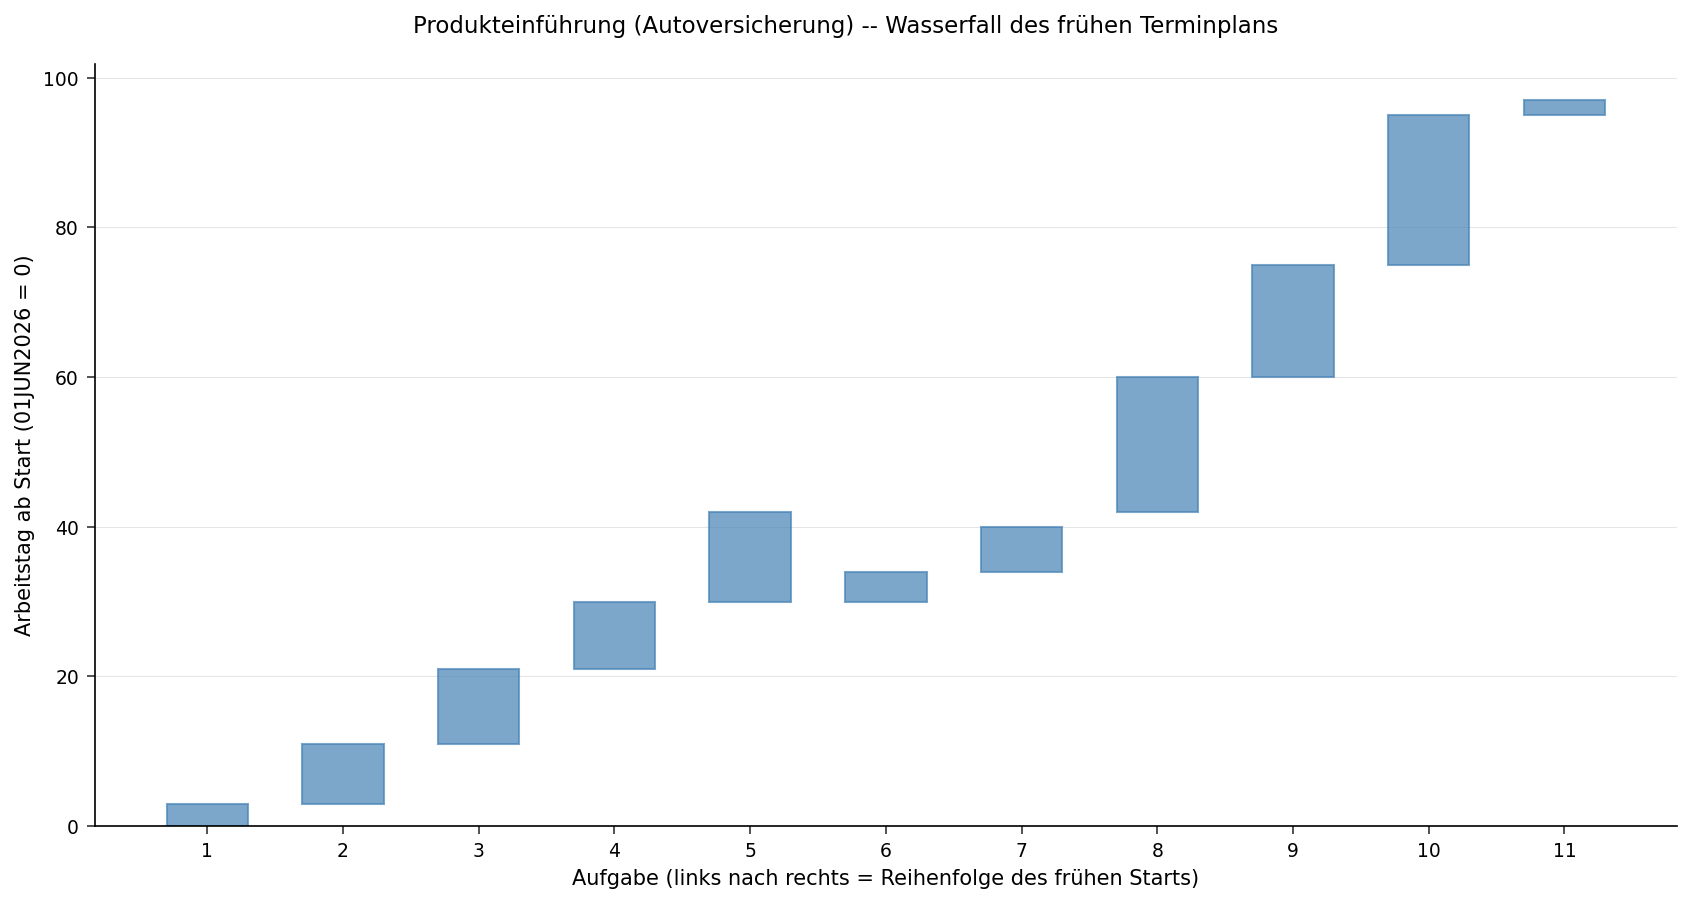

In [8]:
DATEN gantt; FESTLEGEN sched_es;
   ord = es;          /* numerisches x = Reihenfolge des frühen Starts */
AUSFÜHREN;
PROZEDUR SORTIEREN DATEN=gantt; NACH ord activity; AUSFÜHREN;
DATEN gantt; FESTLEGEN gantt; ax = _n_; AUSFÜHREN;   /* kompakter x-Index 1..11 */

ODS GRAPHICS ON / IMAGENAME='gantt' WIDTH=820px HEIGHT=440px;
TITEL 'Produkteinführung (Autoversicherung) -- Wasserfall des frühen Terminplans';
PROZEDUR SGPLOT DATEN=gantt;
   highlow x=ax LOW=es HIGH=ef / type=bar barwidth=0.7;
   XAXIS BEZEICHNUNG='Aufgabe (links nach rechts = Reihenfolge des frühen Starts)'
         integer VALUES=(1 BIS 11 NACH 1);
   YAXIS BEZEICHNUNG='Arbeitstag ab Start (01JUN2026 = 0)' grid;
AUSFÜHREN;
ODS GRAPHICS OFF;

Von links nach rechts gelesen, steigen die Balken kontinuierlich die kritische Kette hinauf. Die beiden Aufgaben, deren Balken die Treppe durchbrechen -- die niedriger starten als die Oberkante des vorhergehenden Balkens -- sind Tarifeinreichung und Genehmigung, die Aktivitäten, die Puffer tragen.

## Gesamtpuffer je Aufgabe

Trägt man den Gesamtpuffer jeder Aufgabe auf, wird der kritische Pfad unverkennbar: Jede kritische Aufgabe sitzt bei null, und nur die beiden aufsichtsrechtlichen Aufgaben ragen darüber hinaus.

                                 Gesamtpuffer je Aufgabe (0 = auf dem kritischen Pfad)                                  




NOTE: ODS Graphics is ON (width=820px, height=380px, format=SVG).
NOTE: Option TITLE changed to Gesamtpuffer je Aufgabe (0 = auf dem kritischen Pfad).
NOTE: PROC SGPLOT data=sched_es

NOTE: PROC SGPLOT output written to: ./ods_output/float.svg
NOTE: ODS Graphics is OFF.


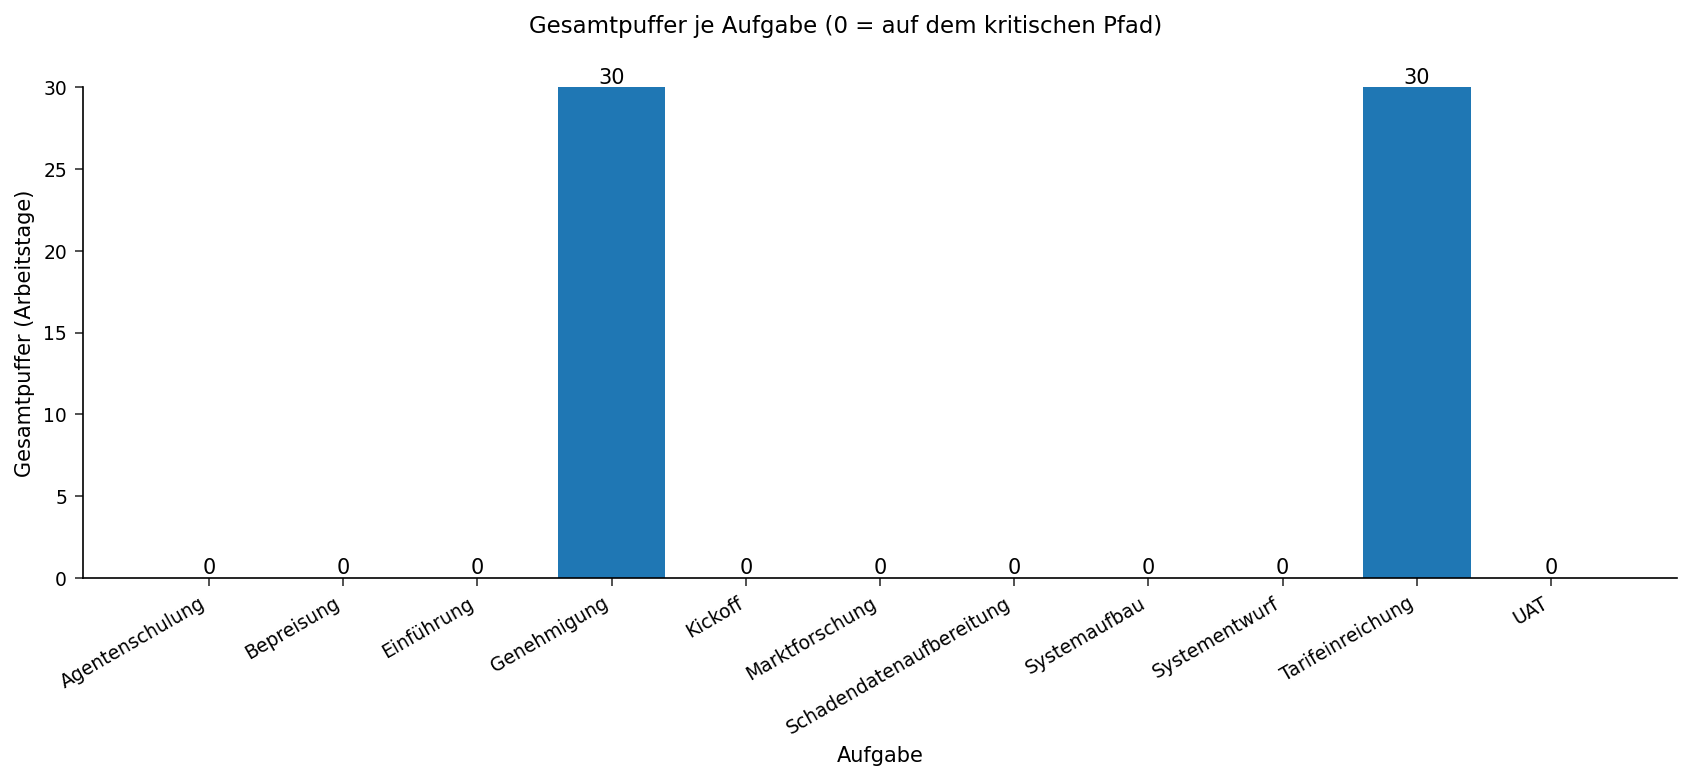

In [9]:
ODS GRAPHICS ON / IMAGENAME='float' WIDTH=820px HEIGHT=380px;
TITEL 'Gesamtpuffer je Aufgabe (0 = auf dem kritischen Pfad)';
PROZEDUR SGPLOT DATEN=sched_es;
   VBAR activity / RESPONSE=tfloat DATALABEL;
   XAXIS BEZEICHNUNG='Aufgabe' fitpolicy=rotatethin;
   YAXIS BEZEICHNUNG='Gesamtpuffer (Arbeitstage)';
AUSFÜHREN;
ODS GRAPHICS OFF;

## Ressourcenauslastung unter dem frühen Terminplan

Über die Terminierung hinaus konkurriert der Plan um zwei Spezialisten-Pools. Expandiert man jede Aufgabe über die Arbeitstage, die sie belegt, und summiert den täglichen Bedarf, ergibt sich das Ressourcenauslastungsprofil -- wie viele Aktuare und Entwickler der Plan täglich benötigt, wenn jede Aufgabe so früh wie möglich startet. Der Spitzenwert ist die höchste Kapazität, die das Programm jemals gleichzeitig erfordert.

                               Maximale tägliche Ressourcenauslastung (früher Terminplan)                               

                                                  The MEANS Procedure

 Variable    Label          Maximum
 ----------------------------------
 ACTUARIES   Aktuare              3
 DEVELOPERS  Entwickler           3
 ----------------------------------

                          Tägliche Auslastung von Aktuaren & Entwicklern im frühen Terminplan                           




NOTE: DATA load

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 10 rows from sched.
NOTE: Wrote load (105 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: Output dataset rprofile has 90 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=rprofile

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 90 rows from rprofile.
NOTE: Wrote rprofile (90 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Maximale tägliche Ressourcenauslastung (früher Terminplan).
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: ODS Graphics is ON (width=820px, height=360px, format=SVG).
NOTE: Option TITLE changed to Tägliche Auslastung von Aktuaren & Entwicklern im frühen Terminplan.
NOTE: PROC SGPLOT data=rprofile

NOTE: PROC SGPLOT output written to: ./ods_output/resload.svg
NOTE: ODS Graphics is OFF.


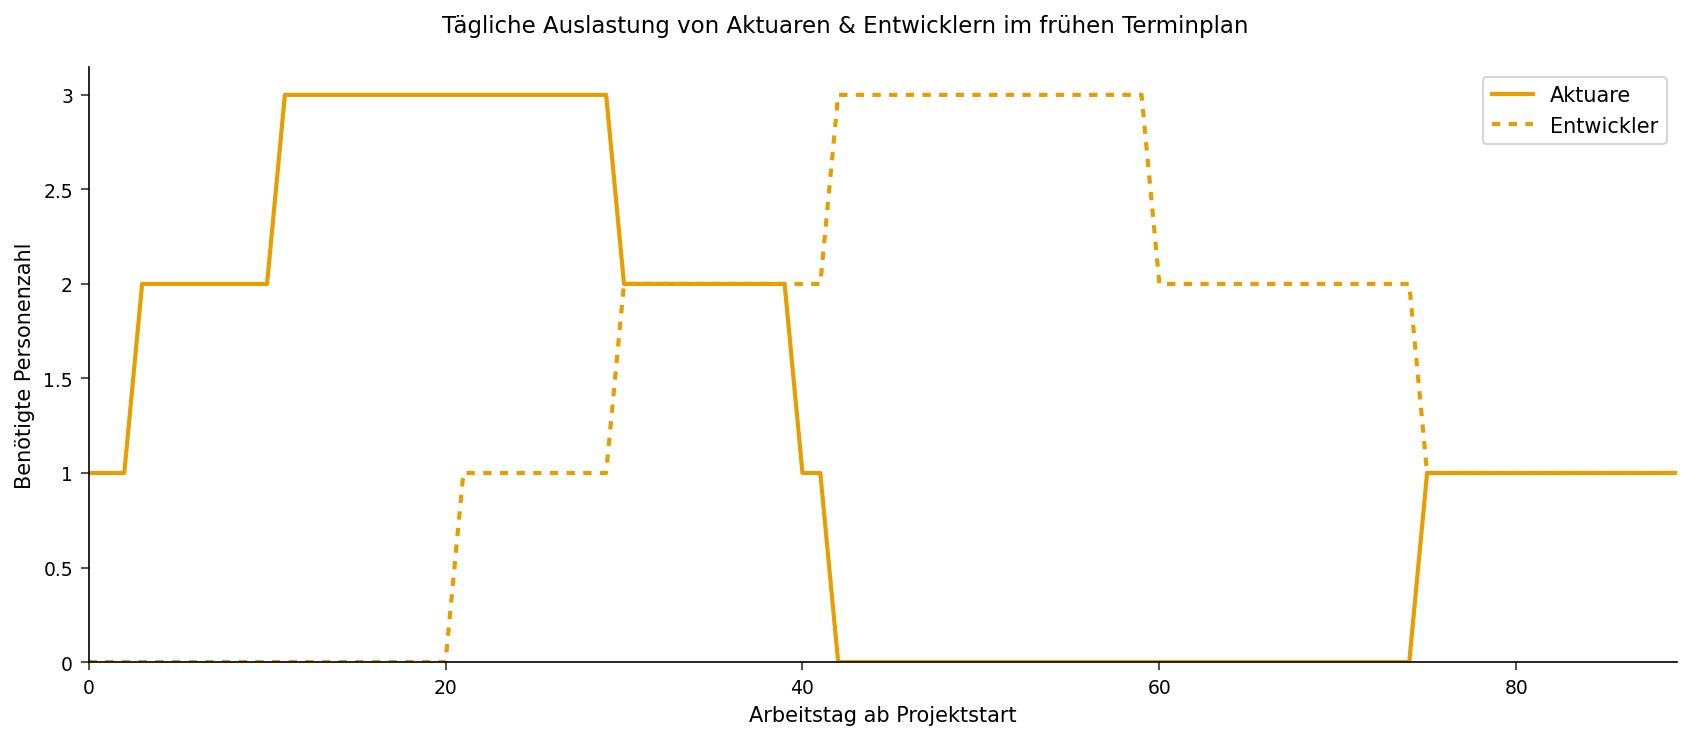

In [10]:
DATEN LOAD;
   FESTLEGEN sched;
   AUSFÜHRUNG d = es BIS ef-1;
      day = d;
      a_use = actuary;
      d_use = developer;
      AUSGABE;
   ENDE;
   BEHALTEN day a_use d_use;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=LOAD NOPRINT NWAY;
   KLASSE day;
   VAR a_use d_use;
   AUSGABE out=rprofile(ENTFERNEN=_type_ _freq_)
          sum(a_use)=actuaries sum(d_use)=developers;
AUSFÜHREN;
PROZEDUR SORTIEREN DATEN=rprofile; NACH day; AUSFÜHREN;

TITEL 'Maximale tägliche Ressourcenauslastung (früher Terminplan)';
PROZEDUR MITTELWERTE DATEN=rprofile MAX maxdec=0;
   VAR actuaries developers;
   BEZEICHNUNG actuaries='Aktuare' developers='Entwickler';
AUSFÜHREN;

ODS GRAPHICS ON / IMAGENAME='resload' WIDTH=820px HEIGHT=360px;
TITEL 'Tägliche Auslastung von Aktuaren & Entwicklern im frühen Terminplan';
PROZEDUR SGPLOT DATEN=rprofile;
   SERIES x=day y=actuaries  /
          LINEATTRS=(thickness=2) legendlabel='Aktuare';
   SERIES x=day y=developers /
          LINEATTRS=(thickness=2 pattern=shortdash)
          legendlabel='Entwickler';
   XAXIS BEZEICHNUNG='Arbeitstag ab Projektstart';
   YAXIS BEZEICHNUNG='Benötigte Personenzahl' MIN=0;
   keylegend / location=inside position=topright;
AUSFÜHREN;
ODS GRAPHICS OFF;

## Interpretation der Ergebnisse

- **Der Einführungstermin wird vom Aufbau-Strang bestimmt, nicht vom aufsichtsrechtlichen Strang.** Der kritische Pfad verläuft Kickoff -> Marktforschung -> Schadendatenaufbereitung -> Bepreisung -> Systementwurf -> Systemaufbau -> UAT -> Agentenschulung -> Einführung, mit einer Gesamtdauer von 97 Arbeitstagen (Ende am 13OCT2026). Jede einzelne dieser Aufgaben hat null Puffer, sodass jede Verzögerung bei ihnen die Einführung Tag um Tag verschiebt.

- **Der aufsichtsrechtliche Zweig hat einen Monat Reserve.** Tarifeinreichung und Genehmigung tragen jeweils 30 Arbeitstage Gesamtpuffer. Nach Abschluss der Bepreisung können sie so spät wie an ihren Spätstart-Terminen beginnen und dennoch rechtzeitig wieder zur Agentenschulung zusammenlaufen, da der parallele Systemaufbauzweig (Systementwurf -> Systemaufbau -> UAT) der längere der beiden Pfade ist, die in die Einführung münden. Planerisch gesprochen ist die Einreichung hier *nicht* die bindende Restriktion -- es ist der Aufbau des Bestandsführungssystems.

- **Der Spezialistenbedarf erreicht seine Spitzen in unterschiedlichen Phasen.** Das Auslastungsprofil zeigt, dass der Aktuarbedarf früh (bis zur Bepreisung) und der Entwicklerbedarf später (bis zum Systemaufbau) seinen Höhepunkt erreicht, jeweils mit einem Maximum von drei Personen pro Tag. Da die beiden Spitzen in verschiedene Phasen fallen, kann ein kleines, sequenzielles Spezialistenteam den Plan besetzen -- das Programm benötigt seinen maximalen Aktuar- und Entwickler-Personalbestand nicht gleichzeitig.

**Fazit für das Geschäft.** CPM verwandelt eine Liste von Einführungsaufgaben in einen umsetzbaren Terminplan: Es identifiziert die Aktivitäten des Aufbau-Strangs, die der Versicherer schützen muss, um den 13OCT2026 zu erreichen, quantifiziert den Monat Reserve, der bei der aufsichtsrechtlichen Einreichung verfügbar ist, und zeigt, dass gestaffelte Aktuar- und Entwicklerspitzen es einem schlanken Spezialistenteam ermöglichen, den Plan umzusetzen.

*Implementierungshinweis:* SAS berechnet dies mit PROC CPM (SAS/OR). Jenner erreicht dasselbe Vorwärts-/Rückwärts-Kritischer-Pfad-Ergebnis mit PROC OPTMODEL, indem es die beiden Längstpfad-Linearprogramme löst, die der Methode zugrunde liegen.